# Projet Time Series

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

import numpy as np
import pandas as pd

from tslearn.datasets import UCR_UEA_datasets

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader, Dataset

from sklearn.metrics import accuracy_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight

import momentfm
from momentfm import MOMENTPipeline

In [8]:
ds = UCR_UEA_datasets()
X_train, y_train, X_test, y_test = ds.load_dataset("LSST")

In [9]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

## Data analysis

In [10]:
print(f"Format X_train : {X_train.shape}") # (nb_samples, nb_timestamps, nb_features)

print(f"Nombre de classes : {len(set(y_train))}")

Format X_train : (2459, 36, 6)
Nombre de classes : 14


In [11]:
print(X_train.shape,
y_train.shape,
X_test.shape,
y_train.shape)

(2459, 36, 6) (2459,) (2466, 36, 6) (2459,)


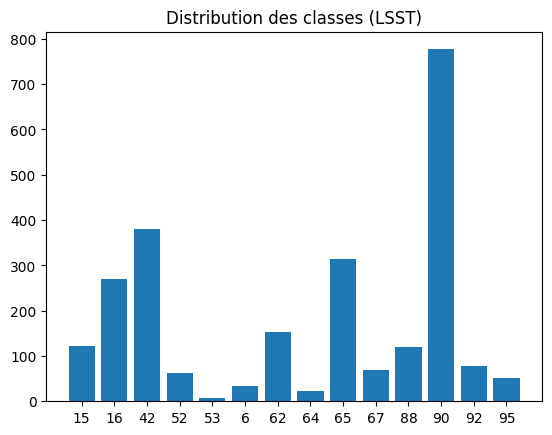

In [12]:
# Distribution des classes
classes, counts = np.unique(y_train, return_counts=True)
plt.bar(classes, counts)
plt.title("Distribution des classes (LSST)")
plt.show()

The classes are heavily imbalanced. We must pay attention to the F1-score when evaluating our models. We might also use the weight parameter in CrossEntropyLoss

In [13]:
weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
weights_tensor = torch.tensor(weights, dtype=torch.float32).to(DEVICE)

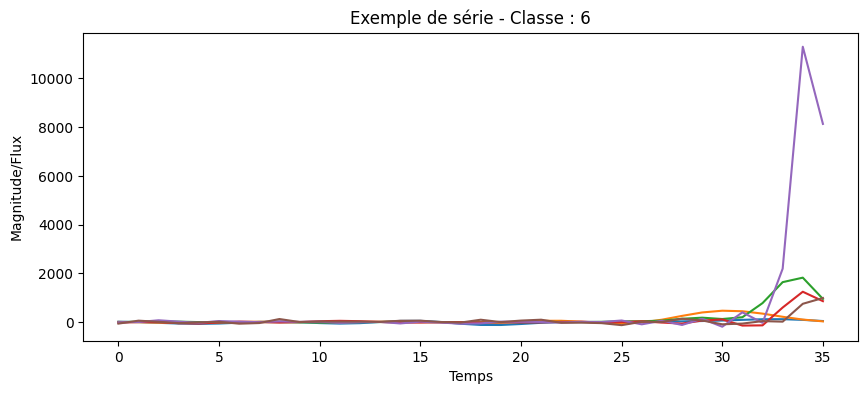

In [14]:
# Visualisation d'une série temporelle
# On affiche la première série (toutes ses features)
plt.figure(figsize=(10, 4))
plt.plot(X_train[0])
plt.title(f"Exemple de série - Classe : {y_train[0]}")
plt.xlabel("Temps")
plt.ylabel("Magnitude/Flux")
plt.show()

## Baseline

In [15]:
N_EPOCHS = 50
BATCH_SIZE = 32
LEARNING_RATE = 0.001

In [16]:
# Encodage des labels de 0 à C-1 (C le nb de classes)
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)
num_classes = len(le.classes_)

# Conversion en Tensors et ajustement des dimensions (Batch, Channels, Length)
# Les données sont (N, 36, 6), PyTorch Conv1D attend (N, 6, 36)
X_train_t = torch.tensor(X_train, dtype=torch.float32).transpose(1, 2).to(DEVICE)
y_train_t = torch.tensor(y_train_encoded, dtype=torch.long).to(DEVICE)
X_test_t = torch.tensor(X_test, dtype=torch.float32).transpose(1, 2).to(DEVICE)
y_test_t = torch.tensor(y_test_encoded, dtype=torch.long).to(DEVICE)

train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(TensorDataset(X_test_t, y_test_t), batch_size=BATCH_SIZE)



In [17]:
class TimeSeriesCNN(nn.Module):
    def __init__(self, in_channels, num_classes):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv1d(in_channels, 64, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.BatchNorm1d(64),
            nn.Conv1d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1)
        )
        self.classifier = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        return self.classifier(x)


In [18]:
model = TimeSeriesCNN(in_channels=X_train.shape[2], num_classes=num_classes).to(DEVICE)
criterion = nn.CrossEntropyLoss(weights_tensor)
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

In [19]:
print(f"Début de l'entraînement pour {N_EPOCHS} époques...")

for epoch in range(N_EPOCHS):
    model.train()
    epoch_loss = 0
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    # Évaluation
    model.eval()
    preds_list, targets_list = [], []
    with torch.no_grad():
        for batch_X, batch_y in test_loader:
            outputs = model(batch_X)
            preds = torch.argmax(outputs, dim=1)
            preds_list.extend(preds.cpu().numpy())
            targets_list.extend(batch_y.cpu().numpy())

    acc = accuracy_score(targets_list, preds_list)
    f1 = f1_score(targets_list, preds_list, average='macro')

    if (epoch + 1) % 5 == 0:
        print(f"Époque [{epoch+1}/{N_EPOCHS}] - Loss: {epoch_loss/len(train_loader):.4f} - Acc: {acc:.4f} - F1: {f1:.4f}")

Début de l'entraînement pour 50 époques...
Époque [5/50] - Loss: 1.9089 - Acc: 0.2271 - F1: 0.2880
Époque [10/50] - Loss: 1.7473 - Acc: 0.4631 - F1: 0.3301
Époque [15/50] - Loss: 1.6731 - Acc: 0.2360 - F1: 0.3431
Époque [20/50] - Loss: 1.6528 - Acc: 0.1853 - F1: 0.1966
Époque [25/50] - Loss: 1.6123 - Acc: 0.2279 - F1: 0.3027
Époque [30/50] - Loss: 1.5111 - Acc: 0.2514 - F1: 0.3202
Époque [35/50] - Loss: 1.5052 - Acc: 0.2818 - F1: 0.3656
Époque [40/50] - Loss: 1.4237 - Acc: 0.2486 - F1: 0.3088
Époque [45/50] - Loss: 1.4073 - Acc: 0.2097 - F1: 0.2876
Époque [50/50] - Loss: 1.4535 - Acc: 0.2413 - F1: 0.2852


## Setting 1 : Adapt a foundation model

In [65]:
def get_moment_model(model_id, num_classes, freeze_encoder=True):
    model = MOMENTPipeline.from_pretrained(
        model_id, 
        model_kwargs={
            "task_name": "embedding", 
            "n_channels": 6, 
            "seq_len": 512, 
            "freeze_encoder": freeze_encoder
        }
    ).to(DEVICE)

    # ACCÈS CORRIGÉ : On passe par .model.config
    hidden_dim = model.config.d_model 
    classifier = nn.Linear(hidden_dim, num_classes).to(DEVICE)
    
    return model, classifier

In [67]:
def train_one_epoch(model, classifier, dataloader, optimizer, criterion, freeze_encoder):
    model.train() if not freeze_encoder else model.eval()
    classifier.train()
    
    total_loss = 0
    for batch_X, batch_y in dataloader:
        batch_X, batch_y = batch_X.to(DEVICE), batch_y.to(DEVICE)
        
        # 1. TRANSPOSITION & PADDING DYNAMIQUE
        # LSST est souvent (N, 36, 6) -> MOMENT veut (N, 6, Time)
        if batch_X.shape[1] == 36: # Si le temps est en dim 1
            batch_X = batch_X.transpose(1, 2)
            
        # On pad dynamiquement jusqu'à 512 peu importe la taille d'entrée
        curr_len = batch_X.shape[-1]
        batch_X_pad = F.pad(batch_X, (0, 512 - curr_len))

        optimizer.zero_grad()
        context_manager = torch.no_grad() if freeze_encoder else torch.enable_grad()
        
        with context_manager:
            # CORRECTION : On ne passe plus d'input_mask, MOMENT va le gérer
            outputs = model.embed(x_enc=batch_X_pad) 
            embeddings = outputs.embeddings if hasattr(outputs, 'embeddings') else outputs
        
        pooled = embeddings.mean(dim=1) if embeddings.dim() == 3 else embeddings
        logits = classifier(pooled)
        
        loss = criterion(logits, batch_y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        
    return total_loss / len(dataloader)

In [69]:
def evaluate(model, classifier, dataloader):
    model.eval()
    classifier.eval()
    all_preds, all_targets = [], []
    
    with torch.no_grad():
        for batch_X, batch_y in dataloader:
            batch_X = batch_X.to(DEVICE)
            if batch_X.shape[1] == 36:
                batch_X = batch_X.transpose(1, 2)
            
            batch_X_pad = F.pad(batch_X, (0, 512 - batch_X.shape[-1]))
            
            # Pas de masque ici non plus
            outputs = model.embed(x_enc=batch_X_pad)
            embeddings = outputs.embeddings if hasattr(outputs, 'embeddings') else outputs
            pooled = embeddings.mean(dim=1) if embeddings.dim() == 3 else embeddings
            
            logits = classifier(pooled)
            preds = torch.argmax(logits, dim=1)
            
            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(batch_y.cpu().numpy())
            
    return accuracy_score(all_targets, all_preds), f1_score(all_targets, all_preds, average='macro')

In [70]:
# --- 4. EXÉCUTION PRINCIPALE ---
def run_experiment(model_id, freeze_encoder, epochs, lr):
    model, classifier = get_moment_model(model_id, num_classes, freeze_encoder)
    
    # Choix des paramètres à optimiser
    params = list(classifier.parameters())
    if not freeze_encoder:
        params += list(model.parameters())
        
    optimizer = torch.optim.AdamW(params, lr=lr)
    # N'oublie pas d'utiliser les weights_tensor calculés précédemment pour la CrossEntropy
    criterion = nn.CrossEntropyLoss(weight=weights_tensor) 

    for epoch in range(epochs):
        avg_loss = train_one_epoch(model, classifier, train_loader, optimizer, criterion, freeze_encoder)
        acc, f1 = evaluate(model, classifier, test_loader)
        
        print(f"Epoch [{epoch+1}/{epochs}] | Loss: {avg_loss:.4f} | Acc: {acc:.4f} | F1: {f1:.4f}")

#### Moment : Linear probing

In [71]:
# --- Lancer le Linear Probing ---
print("Lancement du Linear Probing (MOMENT-small)...")
run_experiment(model_id="AutonLab/MOMENT-1-small", freeze_encoder=True, epochs=20, lr=1e-3)

Lancement du Linear Probing (MOMENT-small)...
Epoch [1/20] | Loss: 2.6211 | Acc: 0.1983 | F1: 0.0658
Epoch [2/20] | Loss: 2.5751 | Acc: 0.1318 | F1: 0.0806
Epoch [3/20] | Loss: 2.5296 | Acc: 0.3435 | F1: 0.1133
Epoch [4/20] | Loss: 2.4963 | Acc: 0.3873 | F1: 0.1204
Epoch [5/20] | Loss: 2.4684 | Acc: 0.3654 | F1: 0.1559
Epoch [6/20] | Loss: 2.4372 | Acc: 0.3885 | F1: 0.1832
Epoch [7/20] | Loss: 2.4118 | Acc: 0.2879 | F1: 0.1649
Epoch [8/20] | Loss: 2.3923 | Acc: 0.3723 | F1: 0.1994
Epoch [9/20] | Loss: 2.3644 | Acc: 0.2948 | F1: 0.1699
Epoch [10/20] | Loss: 2.3545 | Acc: 0.3082 | F1: 0.1836
Epoch [11/20] | Loss: 2.3319 | Acc: 0.2024 | F1: 0.1282
Epoch [12/20] | Loss: 2.3102 | Acc: 0.3114 | F1: 0.1864
Epoch [13/20] | Loss: 2.2956 | Acc: 0.4453 | F1: 0.1742
Epoch [14/20] | Loss: 2.2868 | Acc: 0.4298 | F1: 0.1975
Epoch [15/20] | Loss: 2.2646 | Acc: 0.3354 | F1: 0.2056
Epoch [16/20] | Loss: 2.2620 | Acc: 0.3256 | F1: 0.1900
Epoch [17/20] | Loss: 2.2476 | Acc: 0.3110 | F1: 0.1802
Epoch [18/2

#### Moment : Fine-tuning

In [73]:
# --- Lancer le Fine-Tuning ---
print("\nLancement du Fine-Tuning (MOMENT-small)...")
run_experiment(model_id="AutonLab/MOMENT-1-small", freeze_encoder=False, epochs=10, lr=1e-5)


Lancement du Fine-Tuning (MOMENT-small)...
Epoch [1/10] | Loss: 2.6365 | Acc: 0.2068 | F1: 0.0881
Epoch [2/10] | Loss: 2.4252 | Acc: 0.3208 | F1: 0.1710
Epoch [3/10] | Loss: 2.2267 | Acc: 0.2867 | F1: 0.1974
Epoch [4/10] | Loss: 2.1364 | Acc: 0.3232 | F1: 0.2224
Epoch [5/10] | Loss: 2.0435 | Acc: 0.3200 | F1: 0.2546
Epoch [6/10] | Loss: 1.9681 | Acc: 0.3569 | F1: 0.2658
Epoch [7/10] | Loss: 1.8996 | Acc: 0.3569 | F1: 0.2789
Epoch [8/10] | Loss: 1.8121 | Acc: 0.3589 | F1: 0.3091
Epoch [9/10] | Loss: 1.7629 | Acc: 0.3715 | F1: 0.3209
Epoch [10/10] | Loss: 1.7169 | Acc: 0.3313 | F1: 0.2981


## Setting 2 : Pre-training on forecasting tasks

In [29]:
# Téléchargement direct du dataset ETTh1 (7 variables)
url = "https://raw.githubusercontent.com/zhouhaoyi/ETDataset/main/ETT-small/ETTh1.csv"
df = pd.read_csv(url)
data = df.drop(columns=['date']).values

# Normalisation simple
data = (data - data.mean(axis=0)) / data.std(axis=0)

#### Pre training :

In [30]:
# Variable pour le nombre d'époques
N_EPOCHS_PRETRAIN = 40
BATCH_SIZE = 64
SEQ_LEN = 96  # Longueur de la fenêtre d'entrée
PRED_LEN = 1  # On prédit le point suivant
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [31]:
class InformerDataset(Dataset):
    def __init__(self, data, seq_len, pred_len):
        self.data = torch.tensor(data, dtype=torch.float32)
        self.seq_len = seq_len
        self.pred_len = pred_len

    def __len__(self):
        return len(self.data) - self.seq_len - self.pred_len

    def __getitem__(self, index):
        s_begin = index
        s_end = s_begin + self.seq_len
        r_begin = s_end
        r_end = r_begin + self.pred_len

        seq_x = self.data[s_begin:s_end]
        seq_y = self.data[r_begin:r_end]
        return seq_x, seq_y

train_ds = InformerDataset(data, SEQ_LEN, PRED_LEN)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)

In [32]:
class TransformerForecaster(nn.Module):
    def __init__(self, n_features=7, d_model=128, nhead=8, num_layers=3):
        super().__init__()
        self.input_proj = nn.Linear(n_features, d_model)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=512, batch_first=True
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        # Tête de forecasting (prédit les variables pour le futur proche)
        self.forecasting_head = nn.Linear(d_model, n_features)

    def forward(self, x):
        # x: [Batch, Seq_Len, Features]
        x = self.input_proj(x)
        x = self.encoder(x)
        # On prédit à partir de la dernière représentation temporelle
        out = self.forecasting_head(x[:, -1, :])
        return out

In [33]:
model = TransformerForecaster().to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
criterion = nn.MSELoss() # Utilisation de l'erreur quadratique pour le forecasting

In [34]:
print(f"Début du pré-entraînement sur Informer (ETTh1) pour {N_EPOCHS_PRETRAIN} époques...") #

model.train()
for epoch in range(N_EPOCHS_PRETRAIN): #
    epoch_loss = 0
    for batch_x, batch_y in train_loader:
        batch_x, batch_y = batch_x.to(DEVICE), batch_y.to(DEVICE)

        optimizer.zero_grad()
        outputs = model(batch_x)

        # batch_y est [Batch, Pred_Len, Features], on squeeze pour correspondre à outputs
        loss = criterion(outputs, batch_y.squeeze(1))

        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    print(f"Époque [{epoch+1}/{N_EPOCHS_PRETRAIN}] | Train MSE Loss: {epoch_loss/len(train_loader):.6f}")

# Sauvegarde de l'encodeur pour la phase suivante
torch.save(model.encoder.state_dict(), "pretrained_encoder.pt")
print("Pré-entraînement terminé. Encodeur sauvegardé.")

Début du pré-entraînement sur Informer (ETTh1) pour 40 époques...
Époque [1/40] | Train MSE Loss: 0.236635
Époque [2/40] | Train MSE Loss: 0.142168
Époque [3/40] | Train MSE Loss: 0.135310
Époque [4/40] | Train MSE Loss: 0.131397
Époque [5/40] | Train MSE Loss: 0.129397
Époque [6/40] | Train MSE Loss: 0.126823
Époque [7/40] | Train MSE Loss: 0.124954
Époque [8/40] | Train MSE Loss: 0.123737
Époque [9/40] | Train MSE Loss: 0.122322
Époque [10/40] | Train MSE Loss: 0.121070
Époque [11/40] | Train MSE Loss: 0.119501
Époque [12/40] | Train MSE Loss: 0.118908
Époque [13/40] | Train MSE Loss: 0.117514
Époque [14/40] | Train MSE Loss: 0.116857
Époque [15/40] | Train MSE Loss: 0.115958
Époque [16/40] | Train MSE Loss: 0.115468
Époque [17/40] | Train MSE Loss: 0.114761
Époque [18/40] | Train MSE Loss: 0.113564
Époque [19/40] | Train MSE Loss: 0.112831
Époque [20/40] | Train MSE Loss: 0.112115
Époque [21/40] | Train MSE Loss: 0.110917
Époque [22/40] | Train MSE Loss: 0.110625
Époque [23/40] | Tr

#### Fine tuning

In [35]:
# --- 1. CONFIGURATION ---
# Utilisation d'une variable pour les époques
N_EPOCHS_ADAPT = 60
BATCH_SIZE = 32
LR = 1e-5 # On utilise un taux plus faible pour le fine-tuning
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [36]:
# --- 2. CHARGEMENT DU DATASET LSST ---
# Utilisation de tslearn pour charger LSST
ds = UCR_UEA_datasets()
X_train, y_train, X_test, y_test = ds.load_dataset("LSST")

# Encodage des labels (pour éviter les erreurs d'index hors limites)
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)
num_classes = len(le.classes_)

# Préparation des DataLoaders
train_loader = DataLoader(
    TensorDataset(torch.tensor(X_train, dtype=torch.float32), torch.tensor(y_train_enc, dtype=torch.long)),
    batch_size=BATCH_SIZE, shuffle=True
)
test_loader = DataLoader(
    TensorDataset(torch.tensor(X_test, dtype=torch.float32), torch.tensor(y_test_enc, dtype=torch.long)),
    batch_size=BATCH_SIZE
)

In [37]:
# --- 3. ARCHITECTURE ADAPTÉE ---
class LSSTClassifier(nn.Module):
    def __init__(self, pretrained_encoder_path, d_model=128, num_classes=14):
        super().__init__()
        # On définit la même architecture d'encodeur que pour le pré-entraînement
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=8, dim_feedforward=512, batch_first=True
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=3)

        # Chargement des poids pré-entraînés sur Informer
        self.encoder.load_state_dict(torch.load(pretrained_encoder_path))

        # Adaptation de l'entrée : LSST possède 6 variables
        self.input_proj = nn.Linear(6, d_model)

        # Tête de classification finale
        self.clf_head = nn.Linear(d_model, num_classes)

    def forward(self, x):
        # x: [Batch, 36, 6]
        x = self.input_proj(x)
        x = self.encoder(x)
        # Global Average Pooling (moyenne sur la dimension temporelle)
        x = x.mean(dim=1)
        return self.clf_head(x)

In [38]:
model = LSSTClassifier("pretrained_encoder.pt", num_classes=num_classes).to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
criterion = nn.CrossEntropyLoss(weights_tensor)

In [39]:
# --- 4. BOUCLE DE FINE-TUNING ---
print(f"Début de l'adaptation sur LSST pour {N_EPOCHS_ADAPT} époques...")

for epoch in range(N_EPOCHS_ADAPT):
    model.train()
    total_loss = 0
    for batch_x, batch_y in train_loader:
        batch_x, batch_y = batch_x.to(DEVICE), batch_y.to(DEVICE)

        optimizer.zero_grad()
        outputs = model(batch_x)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    # Évaluation rapide sur le jeu de test [cite: 28]
    model.eval()
    all_preds, all_targets = [], []
    with torch.no_grad():
        for batch_x, batch_y in test_loader:
            batch_x = batch_x.to(DEVICE)
            outputs = model(batch_x)
            preds = torch.argmax(outputs, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(batch_y.numpy())

    acc = accuracy_score(all_targets, all_preds)
    f1 = f1_score(all_targets, all_preds, average='macro')

    print(f"Epoch [{epoch+1}/{N_EPOCHS_ADAPT}] | Loss: {total_loss/len(train_loader):.4f} | Acc: {acc:.4f} | F1: {f1:.4f}")

Début de l'adaptation sur LSST pour 60 époques...
Epoch [1/60] | Loss: 2.6455 | Acc: 0.1233 | F1: 0.0768
Epoch [2/60] | Loss: 2.5412 | Acc: 0.1845 | F1: 0.1228
Epoch [3/60] | Loss: 2.4501 | Acc: 0.2332 | F1: 0.1529
Epoch [4/60] | Loss: 2.3855 | Acc: 0.2587 | F1: 0.1764
Epoch [5/60] | Loss: 2.3216 | Acc: 0.2916 | F1: 0.2090
Epoch [6/60] | Loss: 2.2609 | Acc: 0.3074 | F1: 0.2260
Epoch [7/60] | Loss: 2.2109 | Acc: 0.3240 | F1: 0.2244
Epoch [8/60] | Loss: 2.1681 | Acc: 0.3236 | F1: 0.2260
Epoch [9/60] | Loss: 2.1269 | Acc: 0.3350 | F1: 0.2459
Epoch [10/60] | Loss: 2.0828 | Acc: 0.3273 | F1: 0.2454
Epoch [11/60] | Loss: 2.0439 | Acc: 0.3358 | F1: 0.2634
Epoch [12/60] | Loss: 2.0104 | Acc: 0.3479 | F1: 0.2706
Epoch [13/60] | Loss: 1.9743 | Acc: 0.3739 | F1: 0.2823
Epoch [14/60] | Loss: 1.9495 | Acc: 0.3865 | F1: 0.2821
Epoch [15/60] | Loss: 1.9165 | Acc: 0.3816 | F1: 0.2865
Epoch [16/60] | Loss: 1.8893 | Acc: 0.3771 | F1: 0.2870
Epoch [17/60] | Loss: 1.8544 | Acc: 0.3978 | F1: 0.3038
Epoch [